# Gradient Descent desde Cero

Este notebook implementa Gradient Descent **a mano** para un Perceptron simple (específicamente un ADALINE — una neurona lineal entrenada con Loss MSE).

Objetivos:
1. Ver la regla de actualización de Gradient Descent en NumPy puro — sin autograd.
2. Visualizar el paisaje de la función de costo en 3D.
3. Comparar con la implementación equivalente en PyTorch.

**Prerrequisitos:** [01_intro_neural_networks.ipynb](../01_intro_neural_networks.ipynb)

## ADALINE: un Perceptron lineal con Gradient Descent

**ADALINE** (Adaptive Linear Neuron) es como un Perceptron excepto que:
- Usa una **salida lineal continua** (sin umbral duro durante el entrenamiento).
- Minimiza el **Mean Squared Error** usando Gradient Descent.
- El gradiente tiene una forma cerrada limpia: $\nabla_w J = X^T (\hat{y} - y)$.

Esto lo hace un modelo ideal para entender la mecánica del Gradient Descent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
class ADALINE:
    """Neurona lineal entrenada con Gradient Descent por lotes (Loss MSE)."""

    def __init__(self, lr: float = 0.01, n_iter: int = 50, random_state: int = 1):
        self.lr = lr
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X: np.ndarray, y: np.ndarray) -> "ADALINE":
        rng = np.random.RandomState(self.random_state)
        self.w_ = rng.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.0)
        self.losses_: list[float] = []
        self.w_history_: list[np.ndarray] = []

        for _ in range(self.n_iter):
            output = X @ self.w_ + self.b_
            errors = y - output

            # Gradiente del MSE respecto a Weights y Bias
            self.w_ -= self.lr * (-X.T @ errors)
            self.b_ -= self.lr * (-errors.sum())

            loss = 0.5 * (errors ** 2).sum()
            self.losses_.append(loss)
            if X.shape[1] == 2:
                self.w_history_.append(self.w_.copy())
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return np.where(X @ self.w_ + self.b_ >= 0.0, 1, 0)

## Dataset: compuerta AND

Usamos la compuerta lógica AND — el problema linealmente separable más simple — para enfocarnos en la mecánica del Gradient Descent.

In [3]:
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

print("X:", X_and.tolist())
print("y:", y_and.tolist())

X: [[0, 0], [0, 1], [1, 0], [1, 1]]
y: [0, 0, 0, 1]


## Entrenamiento

In [4]:
model = ADALINE(lr=0.05, n_iter=50, random_state=1)
model.fit(X_and, y_and)

print(f"Weights finales: {model.w_}")
print(f"Bias final:      {model.b_:.4f}")
print(f"Predicciones:    {model.predict(X_and)}")

Weights finales: [0.4242028  0.42248223]
Bias final:      -0.1591
Predicciones:    [0 1 1 1]


## Curva de Loss

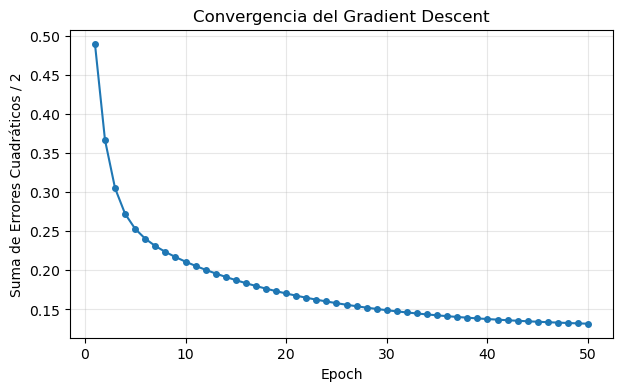

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(model.losses_) + 1), model.losses_, marker="o", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Suma de Errores Cuadráticos / 2")
plt.title("Convergencia del Gradient Descent")
plt.grid(True, alpha=0.3)
plt.show()

## Paisaje de la función de costo (3D)

Fijamos el Bias a su valor final y graficamos el costo como función de `(w₁, w₂)`.

Esta es una simplificación — el paisaje real vive en 3D (w₁, w₂, b) — pero da una imagen clara del "valle" que navega el Gradient Descent.

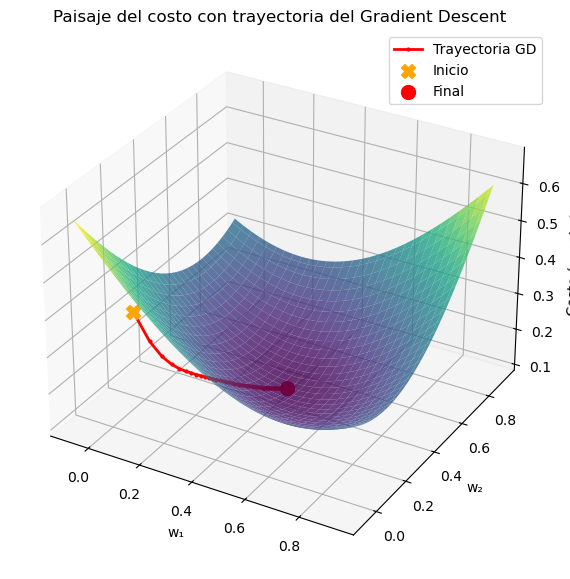

In [6]:
def cost_for_weights(w1, w2, b, X, y):
    output = X @ np.array([w1, w2]) + b
    return np.log1p(0.5 * ((y - output) ** 2).sum())

b_final = model.b_
w_final = model.w_

w1_range = np.linspace(w_final[0] - 0.5, w_final[0] + 0.5, 60)
w2_range = np.linspace(w_final[1] - 0.5, w_final[1] + 0.5, 60)
W1, W2 = np.meshgrid(w1_range, w2_range)
Cost = np.array([cost_for_weights(w1, w2, b_final, X_and, y_and)
                 for w1, w2 in zip(W1.ravel(), W2.ravel())]).reshape(W1.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W1, W2, Cost, cmap="viridis", edgecolor="none", alpha=0.8)

# Superponer trayectoria del Gradient Descent
w_hist = np.array(model.w_history_)
cost_hist = np.log1p(np.array(model.losses_))
ax.plot(w_hist[:, 0], w_hist[:, 1], cost_hist,
        color="red", marker=".", linewidth=2, markersize=4, label="Trayectoria GD")
ax.scatter(*w_hist[0], cost_hist[0], color="orange", marker="X", s=100, label="Inicio")
ax.scatter(*w_hist[-1], cost_hist[-1], color="red", marker="o", s=100, label="Final")

ax.set_xlabel("w₁")
ax.set_ylabel("w₂")
ax.set_zlabel("Costo (escala log)")
ax.set_title("Paisaje del costo con trayectoria del Gradient Descent")
ax.legend()
plt.show()

La trayectoria muestra el Gradient Descent deslizándose por el valle del costo. Con un Learning Rate bien elegido, converge suavemente al mínimo.

## Comparación con PyTorch

El mismo ADALINE en PyTorch requiere **cero matemática de gradientes manual** — `loss.backward()` + `optimizer.step()` lo manejan todo:

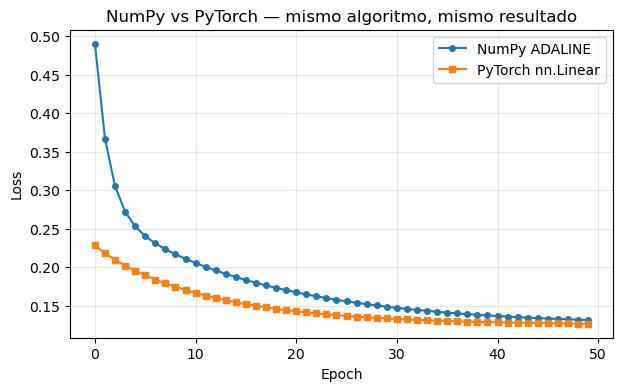

In [7]:
import torch
import torch.nn as nn

X_t = torch.FloatTensor(X_and)
y_t = torch.FloatTensor(y_and).unsqueeze(1)

torch_model = nn.Linear(2, 1)
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.05)
criterion = nn.MSELoss(reduction="sum")

losses_pt = []
for epoch in range(50):
    optimizer.zero_grad()
    loss = 0.5 * criterion(torch_model(X_t), y_t)
    loss.backward()
    optimizer.step()
    losses_pt.append(loss.item())

plt.figure(figsize=(7, 4))
plt.plot(model.losses_, label="NumPy ADALINE", marker="o", markersize=4)
plt.plot(losses_pt, label="PyTorch nn.Linear", marker="s", markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NumPy vs PyTorch — mismo algoritmo, mismo resultado")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Las curvas pueden diferir ligeramente debido a distintas inicializaciones aleatorias, pero el comportamiento de convergencia es idéntico: ambos son Gradient Descent por lotes simple sobre Loss MSE.

La conclusión clave: **el autograd de PyTorch reemplaza la derivación manual de gradientes**. Defines el Forward Pass y la Loss, y PyTorch calcula todos los gradientes automáticamente mediante Backpropagation.

## Qué llevarte de aquí

- El Gradient Descent actualiza los Weights en la dirección que reduce la Loss: $w \leftarrow w - \eta \nabla_w J$.
- El **Learning Rate** ($\eta$) controla el tamaño del paso — demasiado grande diverge, demasiado pequeño es lento.
- El **paisaje del costo** para un modelo lineal es convexo (un solo mínimo) — pero para redes profundas tiene muchos mínimos locales.
- El autograd de PyTorch elimina la necesidad de derivar gradientes manualmente, haciendo trivial entrenar modelos mucho más complejos.